# Live Win Probability Charts

**Navigation**: [← Previous: Modelling](04_modelling.ipynb) | [Next: Evaluation & Case Studies →](06_evaluation_case_studies.ipynb)

Interactive Plotly charts compare ML and DLS probabilities ball-by-ball.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'cricsheet_utils.py').exists():
    PROJ_DIR = Path('projects/cricket-win-probability').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from cricsheet_utils import (
    project_data_dir, load_cricsheet_json, match_metadata, balls_to_dataframe,
    build_game_states, cumulative_runs_by_innings, resource_remaining,
    dls_win_probability,
)
DATA_DIR = project_data_dir()
SAMPLE_DIR = DATA_DIR / 'sample_matches'

import plotly.graph_objects as go
from IPython.display import HTML, display
import joblib
logit = joblib.load(DATA_DIR / 'logit_model.joblib')
lgbm = joblib.load(DATA_DIR / 'lgbm_model.joblib')
feature_cols = [
    'runs_scored', 'wickets_lost', 'balls_remaining', 'wickets_remaining',
    'runs_required', 'runs_required_per_ball', 'current_run_rate',
    'overs_completed', 'phase_powerplay', 'phase_death',
]


In [2]:
def win_prob_states(doc):
    states = build_game_states(doc).copy()
    first_runs = int(states['target'].iloc[0] - 1)
    states['dls_prob'] = dls_win_probability(states, first_runs)
    states['ml_prob'] = lgbm.predict_proba(states[feature_cols])[:, 1]
    return states

def win_prob_chart(doc, title):
    """Plotly figure; use display_plotly() so Jupyter Book embeds HTML."""
    states = win_prob_states(doc)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=states['overs_completed'], y=states['ml_prob'],
                             mode='lines', name='LightGBM', line=dict(color='#1565c0', width=2)))
    fig.add_trace(go.Scatter(x=states['overs_completed'], y=states['dls_prob'],
                             mode='lines', name='DLS baseline', line=dict(color='#2e7d32', width=2, dash='dash')))
    wicket_rows = states[states['ball_number'].isin(
        balls_to_dataframe(doc).query('innings == 2 and is_wicket == 1')['ball_number']
    )]
    for _, w in wicket_rows.iterrows():
        fig.add_vline(x=w['overs_completed'], line_width=1, line_dash='dot', line_color='gray', opacity=0.4)
    fig.update_layout(title=title, xaxis_title='Overs (chase)', yaxis_title='P(win)',
                      yaxis=dict(range=[0, 1]), template='plotly_white', height=450)
    return fig

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

def plot_win_prob_mpl(states, title, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(states['overs_completed'], states['ml_prob'], label='LightGBM', color='#1565c0', linewidth=2)
    ax.plot(states['overs_completed'], states['dls_prob'], label='DLS baseline', color='#2e7d32', linewidth=2, linestyle='--')
    ax.set_xlabel('Overs (chase)')
    ax.set_ylabel('P(win)')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120)
    plt.show()
    return fig


## 2019 World Cup Final

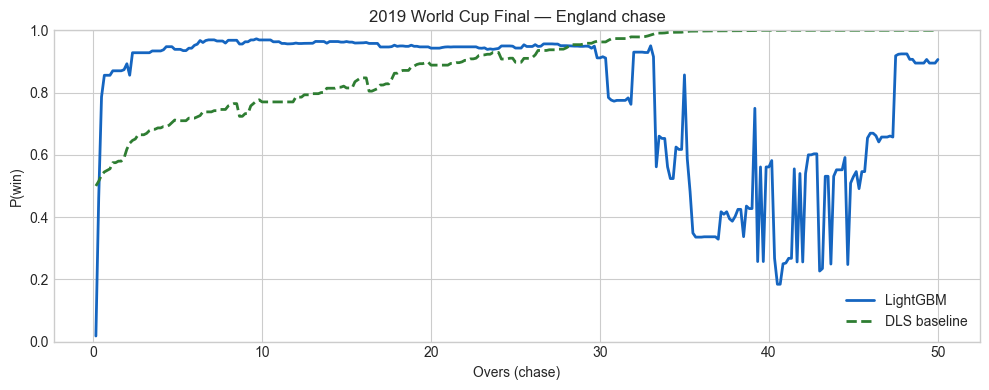

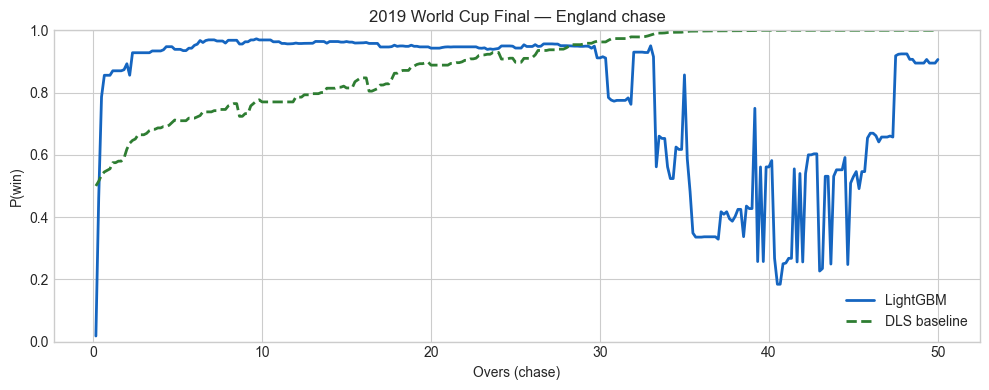

In [3]:
doc = load_cricsheet_json(SAMPLE_DIR / '2019_wc_final_eng_nz.json')
states = win_prob_states(doc)
display_plotly(win_prob_chart(doc, '2019 World Cup Final — England chase'))
plot_win_prob_mpl(
    states,
    '2019 World Cup Final — England chase',
    save_path=PROJ_DIR / 'figures' / '05_wc2019_winprob.png',
)


## 2011 World Cup Quarter-Final — India chase

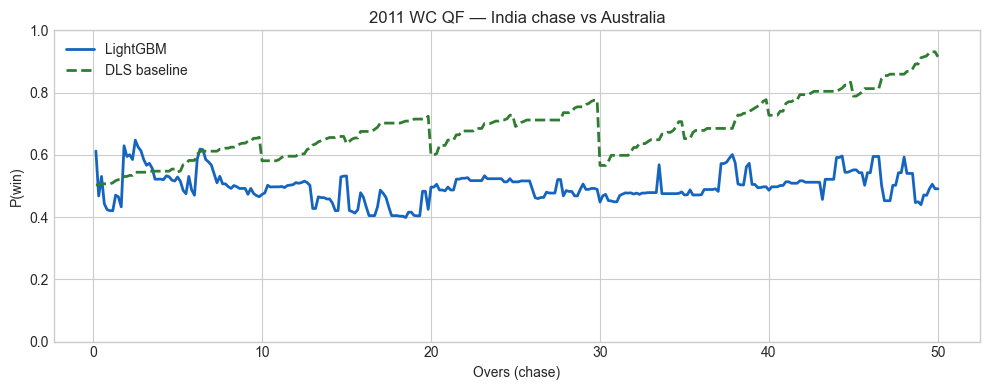

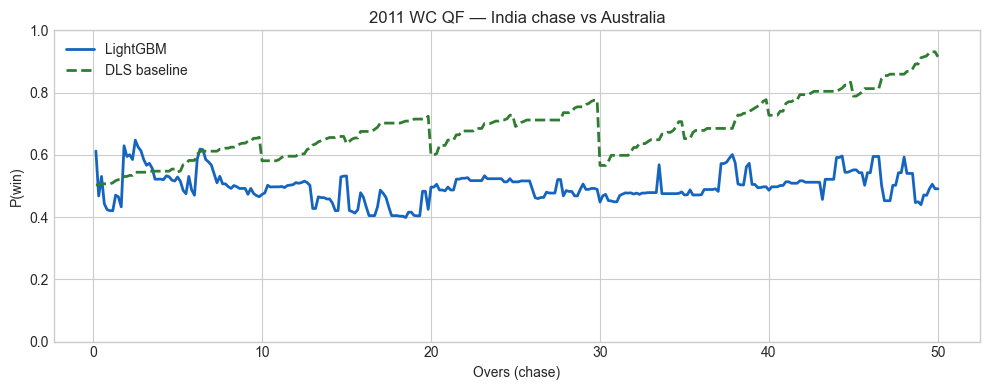

In [4]:
doc2 = load_cricsheet_json(SAMPLE_DIR / '2011_wc_qf_ind_aus.json')
states2 = win_prob_states(doc2)
display_plotly(win_prob_chart(doc2, '2011 WC QF — India chase vs Australia'))
plot_win_prob_mpl(states2, '2011 WC QF — India chase vs Australia')


---

**Navigation**: [← Previous: Modelling](04_modelling.ipynb) | [Next: Evaluation & Case Studies →](06_evaluation_case_studies.ipynb)
